# Compare results

This notebook will show you the results of retrieval and generation evaluation.

In [13]:
generation_paths = ['./data/generation_eval_results_naive.csv', 
                    './data/generation_eval_results_em.csv',
                    './data/generation_eval_results_em_rr_k.csv',
                    './data/generation_eval_results_em_ch_rr_k.csv',
                    './data/generation_eval_results_em_ch_rr_k_mf.csv',
                    './data/generation_eval_results_em_ch_rr_k_hs.csv']

retrieval_paths = ['./data/retrieval_eval_results_naive.csv',
                   './data/retrieval_eval_results_em.csv',
                   './data/retrieval_eval_results_em_rr_k.csv',
                   './data/retrieval_eval_results_em_ch_rr_k.csv',
                   './data/retrieval_eval_results_em_ch_rr_k_mf.csv',
                   './data/retrieval_eval_results_em_ch_rr_k_hs.csv']

retrieval2_paths = ['./data/retrieval_eval_results_naive.csv',
                    './data/retrieval_eval_results_em.csv',
                    './data/retrieval_eval_results_em_rr_k.csv',
                    './data/retrieval_eval_results_em_ch_rr_k2.csv',
                    './data/retrieval_eval_results_em_ch_rr_k_mf2.csv',
                    './data/retrieval_eval_results_em_ch_rr_k_hs2.csv']

In [14]:
import pandas as pd

retrieval_dfs = []
for path in retrieval_paths:
    df = pd.read_csv(path)
    df["configuration"] = path
    retrieval_dfs.append(df)

retrieval_df = pd.concat(retrieval_dfs, ignore_index=True)

retrieval2_dfs = []
for path in retrieval2_paths:
    df = pd.read_csv(path)
    df["configuration"] = path
    retrieval2_dfs.append(df)

retrieval2_df = pd.concat(retrieval2_dfs, ignore_index=True)

generation_dfs = []
for path in generation_paths:
    df = pd.read_csv(path)
    df["configuration"] = path
    generation_dfs.append(df)

generation_df = pd.concat(generation_dfs, ignore_index=True)

In [15]:
retrieval_df['Configuration'] = ['Naive', 'EM', 'EM + RR-K', 'EM + CH + RR-K', 'EM + CH + RR-K + MF', 'EM + CH + RR-K + HS']
retrieval2_df['Configuration'] = ['Naive', 'EM', 'EM + RR-K', 'EM + CH + RR-K', 'EM + CH + RR-K + MF', 'EM + CH + RR-K + HS']
generation_df['Configuration'] = ['Naive', 'EM', 'EM + RR-K', 'EM + CH + RR-K', 'EM + CH + RR-K + MF', 'EM + CH + RR-K + HS']

In [16]:
retrieval_df[['Configuration'] + [c for c in retrieval_df.columns if c.startswith('soft') and c != "soft_covered_reference_count"]]

,Configuration,soft_hit_rate,soft_precision,soft_recall,soft_mrr,soft_avg_retrieved_max_similarity,soft_avg_reference_max_similarity,soft_relevant_retrieved_count
0,Naive,0.780083,0.341079,0.780083,0.708575,0.650019,0.867581,1.705394
1,EM,0.991701,0.858091,0.991701,0.957261,0.803547,0.920538,4.290456
2,EM + RR-K,0.954357,0.924620,0.954357,0.941909,0.868149,0.911489,2.153527
3,EM + CH + RR-K,0.970954,0.929391,0.970954,0.961618,0.863332,0.907619,2.248963
4,EM + CH + RR-K + MF,0.846473,0.803873,0.846473,0.841286,0.825862,0.861097,1.817427
5,EM + CH + RR-K + HS,0.925311,0.884025,0.925311,0.917012,0.845898,0.880036,1.742739


In [17]:
retrieval2_df[['Configuration'] + [c for c in retrieval2_df.columns if c.startswith('soft') and c != "soft_covered_reference_count"]]

,Configuration,soft_hit_rate,soft_precision,soft_recall,soft_mrr,soft_avg_retrieved_max_similarity,soft_avg_reference_max_similarity,soft_relevant_retrieved_count
0,Naive,0.780083,0.341079,0.780083,0.708575,0.650019,0.867581,1.705394
1,EM,0.991701,0.858091,0.991701,0.957261,0.803547,0.920538,4.290456
2,EM + RR-K,0.954357,0.924620,0.954357,0.941909,0.868149,0.911489,2.153527
3,EM + CH + RR-K,0.970954,0.929391,0.970954,0.961618,0.862563,0.906849,2.248963
4,EM + CH + RR-K + MF,0.846473,0.803873,0.846473,0.841286,0.825862,0.861097,1.817427
5,EM + CH + RR-K + HS,0.925311,0.883057,0.925311,0.917012,0.846362,0.880699,1.738589


In [18]:
generation_df['Configuration'] = ['Naive', 'EM', 'EM + RR-K', 'EM + CH + RR-K', 'EM + CH + RR-K + MF', 'EM + CH + RR-K + HS']
generation_df[['Configuration'] + [c for c in generation_df.columns if c.endswith('score')]]

,Configuration,faithfulness_avg_score,relevancy_avg_score,correctness_avg_score,llm_judge_avg_score,semantic_similarity_avg_score
0,Naive,0.866667,0.866667,3.533333,3.800000,0.782496
1,EM,0.866667,0.933333,4.200000,4.400000,0.845929
2,EM + RR-K,0.800000,0.600000,3.966667,4.000000,0.851452
3,EM + CH + RR-K,1.000000,0.800000,3.966667,4.266667,0.849698
4,EM + CH + RR-K + MF,0.866667,0.600000,3.333333,3.600000,0.811836
5,EM + CH + RR-K + HS,1.000000,0.800000,3.800000,4.133333,0.855246


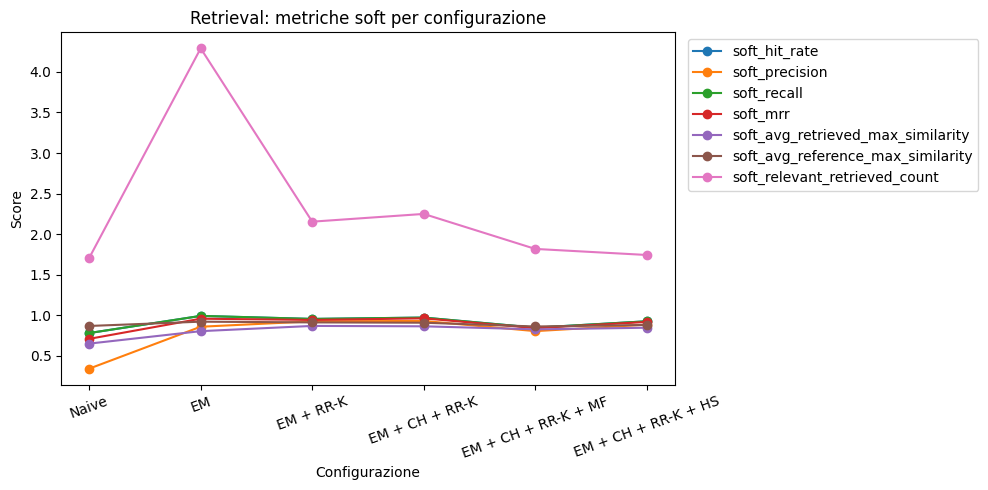

In [19]:
import matplotlib.pyplot as plt

configs = retrieval_df['Configuration'].tolist()
soft_cols = [c for c in retrieval_df.columns if c.startswith('soft') and c != "soft_covered_reference_count"]

fig, ax = plt.subplots(figsize=(10, 5))
for col in soft_cols:
    ax.plot(configs, retrieval_df[col], marker='o', label=col)

ax.set_xlabel('Configurazione')
ax.set_ylabel('Score')
ax.set_title('Retrieval: metriche soft per configurazione')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

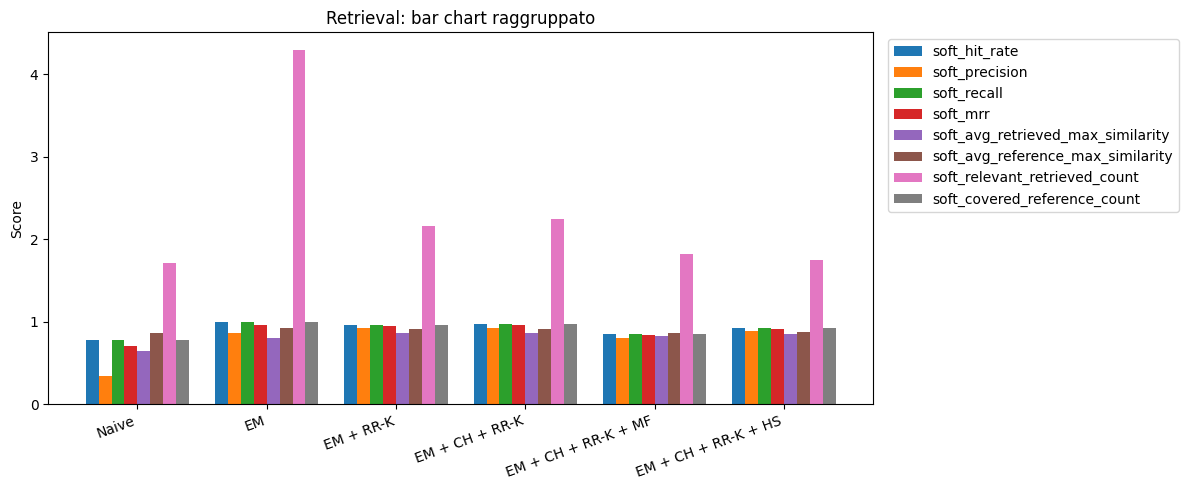

In [20]:
import matplotlib.pyplot as plt
import numpy as np

configs = retrieval_df['Configuration'].tolist()
soft_cols = [c for c in retrieval_df.columns if c.startswith('soft')]

x = np.arange(len(configs))
width = 0.8 / len(soft_cols)

fig, ax = plt.subplots(figsize=(12, 5))
for i, col in enumerate(soft_cols):
    offset = (i - len(soft_cols) / 2) * width + width / 2
    ax.bar(x + offset, retrieval_df[col], width, label=col)

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Retrieval: bar chart raggruppato')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


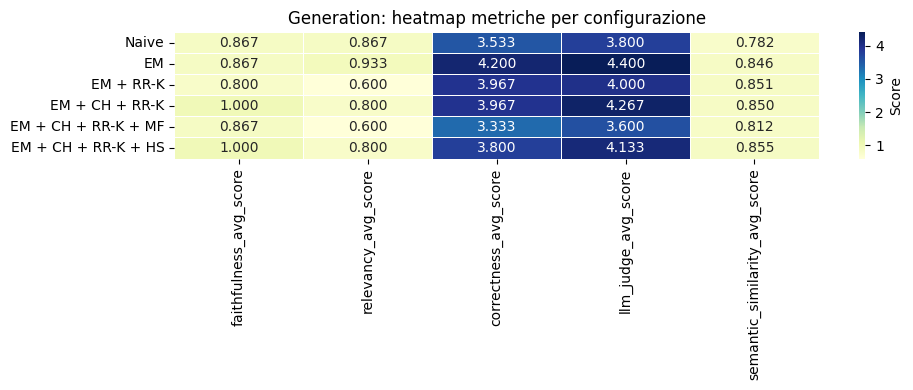

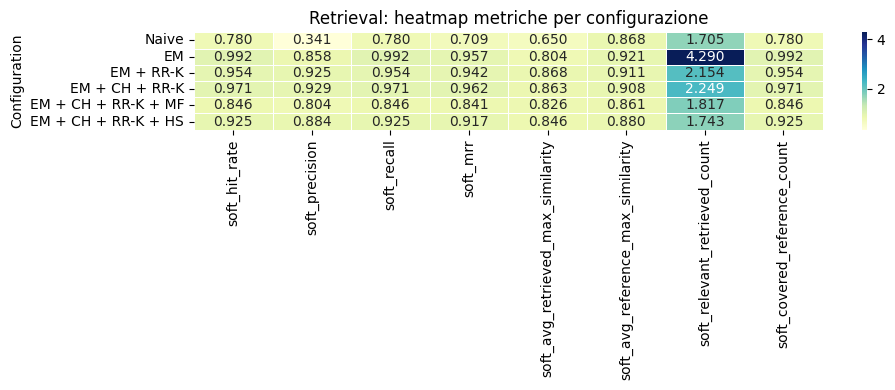

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

score_cols = [c for c in generation_df.columns if c.endswith('score')]
data = generation_df.set_index('Configuration')[score_cols]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    data,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
)
ax.set_title('Generation: heatmap metriche per configurazione')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Stesso plot per retrieval
soft_cols = [c for c in retrieval_df.columns if c.startswith('soft')]
data_r = retrieval_df.set_index('Configuration')[soft_cols]

fig2, ax2 = plt.subplots(figsize=(10, 4))
sns.heatmap(data_r, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax2, linewidths=0.5)
ax2.set_title('Retrieval: heatmap metriche per configurazione')
plt.tight_layout()
plt.show()

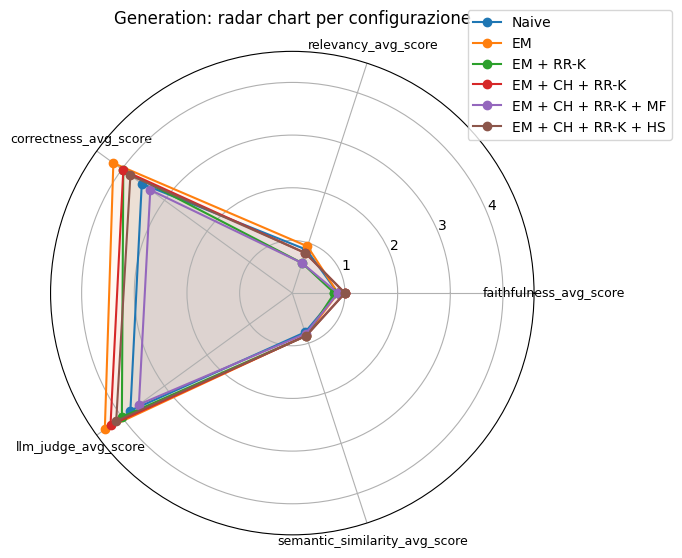

In [23]:
import matplotlib.pyplot as plt
import numpy as np

score_cols = [c for c in generation_df.columns if c.endswith('score')]
configs = generation_df['Configuration'].tolist()
values_matrix = generation_df[score_cols].values

N = len(score_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # chiude il poligono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, config in enumerate(configs):
    vals = values_matrix[i].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, label=config, marker='o')
    ax.fill(angles, vals, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(score_cols, size=9)
ax.set_title('Generation: radar chart per configurazione', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

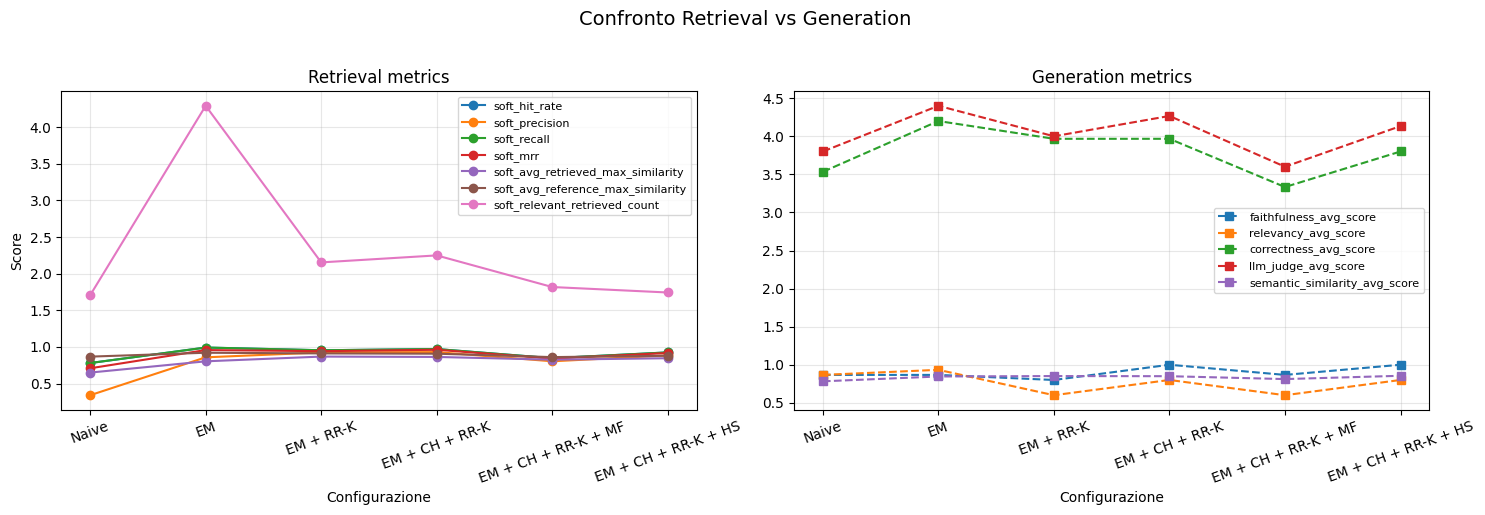

In [24]:
import matplotlib.pyplot as plt

configs = retrieval_df['Configuration'].tolist()
soft_cols = [c for c in retrieval_df.columns if c.startswith('soft') and c != "soft_covered_reference_count"]
score_cols = [c for c in generation_df.columns if c.endswith('score')]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Retrieval
for col in soft_cols:
    axes[0].plot(configs, retrieval_df[col], marker='o', label=col)
axes[0].set_title('Retrieval metrics')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)

# Generation
for col in score_cols:
    axes[1].plot(configs, generation_df[col], marker='s', linestyle='--', label=col)
axes[1].set_title('Generation metrics')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('Configurazione')
    ax.grid(True, alpha=0.3)

plt.suptitle('Confronto Retrieval vs Generation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()